# Corrective RAG or CRAG [Naive Implementation]


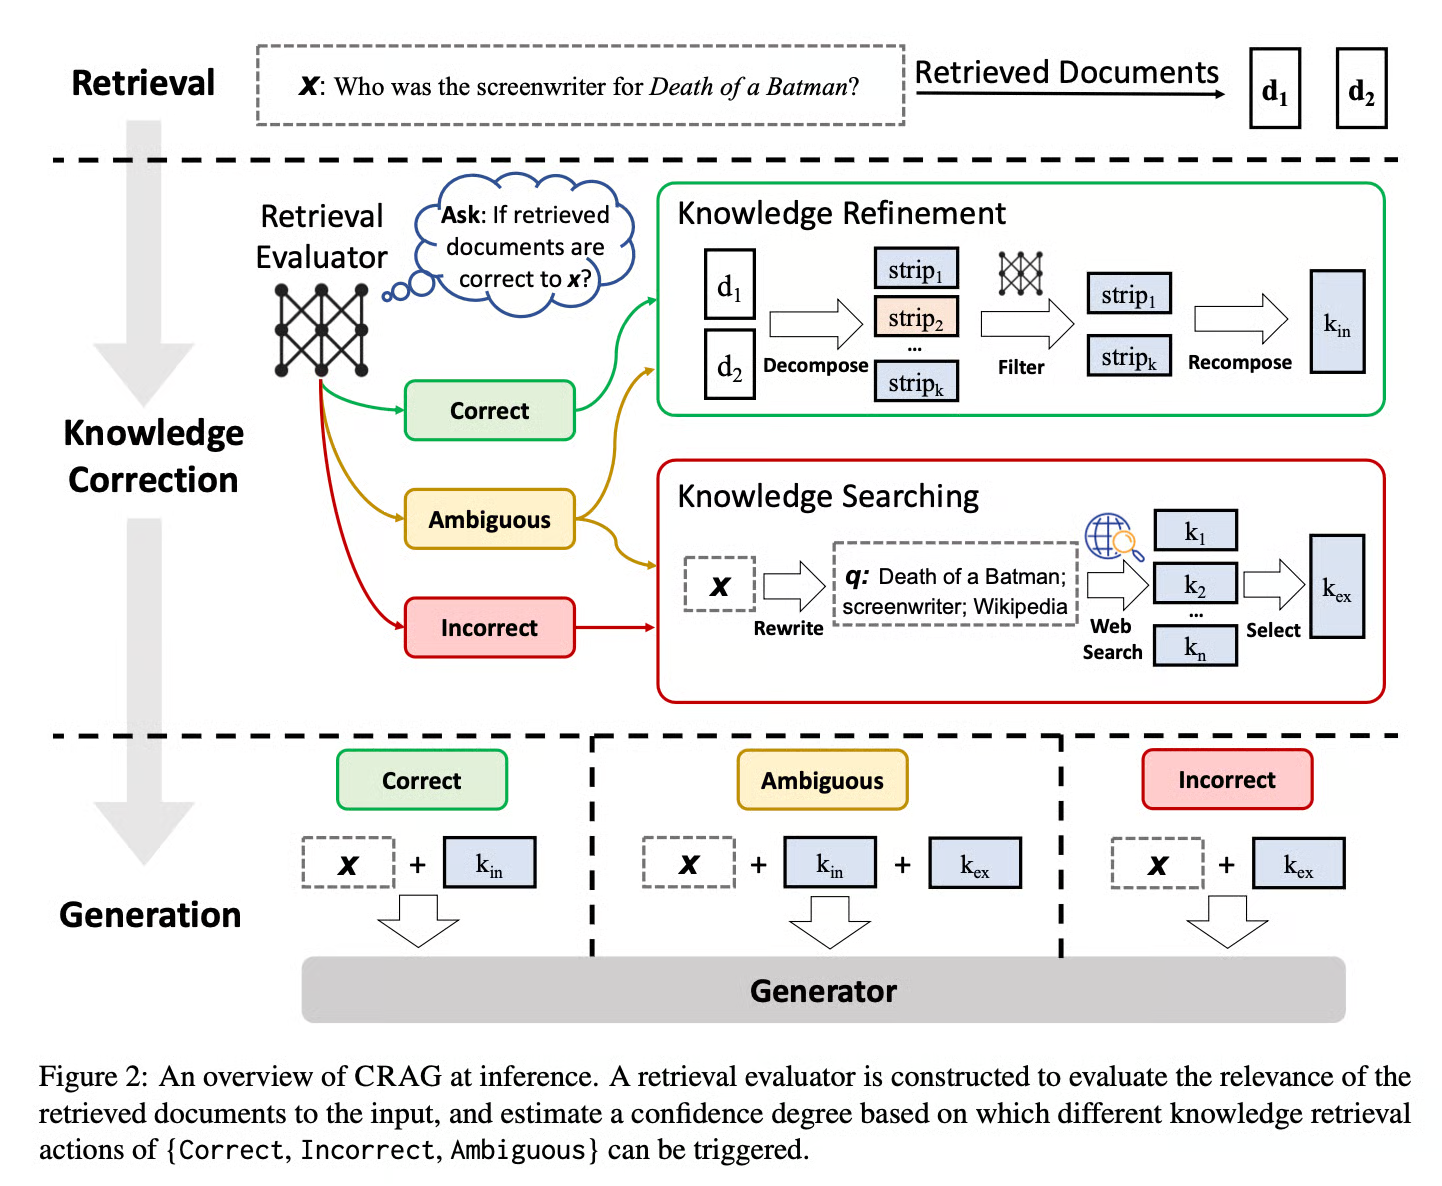

<li> Corrective Retrieval Augmented Generation (CRAG) is an enhanced version of Retrieval-Augmented Generation (RAG) that improves the accuracy and reliability of generated responses.
<li> Self-Correction Mechanism: CRAG incorporates a self-correction mechanism that evaluates and refines retrieved knowledge, reducing errors and improving accuracy. 

<li> Retrieval Evaluator: It features a lightweight retrieval evaluator that assesses the quality of retrieved documents, assigning confidence scores to ensure only relevant information is used. 

<li> Dynamic Knowledge: CRAG utilizes large-scale web searches to augment the retrieval results, ensuring that the information is current and relevant. 

<li> Algorithmic Improvement: The algorithm includes a decompose-then-recompose approach to selectively focus on key information and filter out irrelevant details. 


<li> CRAG significantly enhances the performance of RAG-based approaches by addressing issues like irrelevant retrieval, noise, and hallucinations

In [1]:
CORPUS = """
Naruto follows the journey of Naruto Uzumaki, a young ninja striving for recognition and aiming to become the Hokage, the leader of his village.
Overview
"Naruto" is a Japanese manga series written and illustrated by Masashi Kishimoto, serialized from 1999 to 2014, spanning 700 chapters collected in 72 volumes. The story is set in a world of ninja villages reminiscent of feudal Japan and follows Naruto Uzumaki, a spirited and socially isolated boy who harbors the Nine-Tailed Demon Fox sealed within him by the Fourth Hokage to protect his village, Konohagakure (Konoha).

Early Life and Motivation
Orphaned and shunned by villagers due to the demon fox inside him, Naruto grows up craving acknowledgment and dreams of becoming the Hokage, the strongest leader of Konoha. Despite his mischievous behavior, he is determined to prove his worth and gain respect.

Team 7 and Ninja Academy
Upon graduating from the ninja academy, Naruto is assigned to Team 7, alongside Sakura Haruno and his rival Sasuke Uchiha, under the guidance of Kakashi Hatake. The team embarks on missions that test their skills, teamwork, and resolve, including the Land of Waves mission and the Chūnin Exams, where they face formidable opponents and uncover deeper threats to their village.

Major Arcs
Sasuke Retrieval Arc: Naruto struggles to prevent Sasuke from defecting to Orochimaru, a rogue ninja seeking power. This arc explores themes of friendship, loyalty, and vengeance.
Shippuden / Part II: Set during Naruto's teenage years, this part delves into larger conflicts, including the Akatsuki organization, the history of the ninja world, and Naruto's growth as a ninja and leader.
Mentorship and Growth: Naruto learns from mentors like Jiraiya and Kakashi, who guide him in mastering powerful techniques and understanding the responsibilities of leadership.
Themes
The series explores identity, isolation, ambition, and the cycle of revenge, often revisiting these themes through recurring arcs and mentor-student relationships. Naruto’s journey emphasizes perseverance, the value of bonds, and the moral complexities of leadership.

Legacy
"Naruto" has become one of the best-selling manga series worldwide, with 250 million copies in circulation. Its story continues in Boruto, following Naruto’s son as he navigates his own path as a ninja. The franchise includes anime adaptations, films, OVAs, light novels, video games, and merchandise, cementing its status as a cornerstone of modern manga and anime culture.
"""

In [ ]:
from langchain_ollama.llms import OllamaLLM
from langchain_core.prompts import PromptTemplate
from langchain_ollama.embeddings import OllamaEmbeddings
from tqdm import tqdm
from typing import List, Dict, Any
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, START, END
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from joblib import Parallel, delayed


C:\Users\NITIN KHANNA\AppData\Local\Temp\ipykernel_6584\3884624359.py:8: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


"Hello! It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [48]:

llm = OllamaLLM(model="gemma4:12b", base_url="http://localhost:11434")
llm.invoke("Hello, world!")

'Hello! How can I help you today?'

In [3]:
embeddings = OllamaEmbeddings(model="nomic-embed-text",base_url="http://localhost:11434")
embeddings.embed_query("Hello, world!")

[0.015944712,
 -0.00066871266,
 -0.15884711,
 -0.012639722,
 -0.017772568,
 0.06133935,
 -0.005530181,
 -0.010648055,
 -0.005595036,
 -0.040752854,
 0.013812525,
 0.073206596,
 0.019417692,
 0.051153924,
 0.02694915,
 -0.05959994,
 0.0075575723,
 -0.0624982,
 -0.029500596,
 0.025304249,
 -0.031721555,
 -0.0891535,
 0.008556844,
 0.019887969,
 0.122902624,
 0.009026655,
 -0.03740906,
 0.071798116,
 0.012575642,
 -0.0032125225,
 -0.00511416,
 0.007725428,
 -0.0016875543,
 0.034024406,
 0.056571875,
 0.0003571958,
 0.022016114,
 0.0075302306,
 0.024647944,
 -0.02610725,
 0.012729344,
 -0.00060400285,
 0.012777835,
 0.00581084,
 0.07581964,
 -0.01730959,
 -0.019308375,
 -0.034218125,
 0.069997266,
 -0.035499062,
 -0.046173614,
 -0.0073391455,
 -0.0038173567,
 0.05511746,
 0.047126174,
 0.016569518,
 0.053478383,
 -0.035700463,
 0.018310279,
 0.05555609,
 0.04177626,
 0.05430309,
 0.028133187,
 0.03241012,
 0.0007847987,
 -0.04756514,
 -0.014137421,
 0.0735616,
 0.023639591,
 0.009261301,
 

In [4]:
docs = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=30).split_documents([Document(page_content=c) for c in CORPUS.split("\n")])
print(f"Number of documents: {len(docs)}")
print(docs)

Number of documents: 24
[Document(metadata={}, page_content='Naruto follows the journey of Naruto Uzumaki, a young ninja striving for recognition and aiming to become the Hokage, the leader of his village.'), Document(metadata={}, page_content='Overview'), Document(metadata={}, page_content='"Naruto" is a Japanese manga series written and illustrated by Masashi Kishimoto, serialized from 1999 to 2014, spanning 700 chapters collected in 72 volumes. The story is set in a world of ninja'), Document(metadata={}, page_content='is set in a world of ninja villages reminiscent of feudal Japan and follows Naruto Uzumaki, a spirited and socially isolated boy who harbors the Nine-Tailed Demon Fox sealed within him by the Fourth'), Document(metadata={}, page_content='within him by the Fourth Hokage to protect his village, Konohagakure (Konoha).'), Document(metadata={}, page_content='Early Life and Motivation'), Document(metadata={}, page_content='Orphaned and shunned by villagers due to the demon 

In [5]:
vectorstore = FAISS.from_documents(docs, embeddings)
retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 5})

In [6]:
type(retriever.invoke( "Who is Naruto?"))

list

In [7]:
class State():
    question: str
    answer: str
    retrieved_docs: List[Document]



'### Simple RAG Implementation'

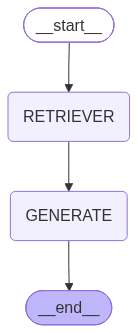

In [8]:
def retrieve_docs(state):
    q = state['question']
    try: 
        relevant_docs = retriever.invoke(q)
        # print(f"Retrieved {len(relevant_docs)} documents for question: {q}")
    except Exception as e:
        print(f"Error occurred while retrieving documents: {e}")
        relevant_docs = []

    # print(state)
    return {'retrieved_docs': relevant_docs}




def generate_answer(state):
    print(state)
    prompt = PromptTemplate(
    input_variables=["question", "retrieved_docs"], 
    template="""You are a helpful assistant that answers questions based on the provided context.
                Answer the question using the context below. If the answer is not contained within the text below, say "I don't know".
                Question: {question}
                Context: {retrieved_docs}
                Answer:""")
    context = "\n".join([doc.page_content for doc in state['retrieved_docs']])
    prompt_text = prompt.format(question=state['question'], retrieved_docs=context)
    
    answer = llm.invoke(prompt_text)
    return {'answer': answer}


graph = StateGraph(State)
graph.add_node("RETRIEVER", retrieve_docs)
graph.add_node("GENERATE", generate_answer)
graph.add_edge(START, "RETRIEVER")
graph.add_edge("RETRIEVER", "GENERATE")
graph.add_edge("GENERATE", END)

app = graph.compile()
display("### Simple RAG Implementation")
app

In [9]:
response = app.invoke({"question": "Who is Naruto?", "answer": "", "retrieved_docs": []})
print(response['answer'])

{'question': 'Who is Naruto?', 'answer': '', 'retrieved_docs': [Document(id='068805e3-dfcf-4e32-b215-0e5bf42c2211', metadata={}, page_content='"Naruto" is a Japanese manga series written and illustrated by Masashi Kishimoto, serialized from 1999 to 2014, spanning 700 chapters collected in 72 volumes. The story is set in a world of ninja'), Document(id='8364c080-8641-4a95-ae29-7d8e3a3fa7b8', metadata={}, page_content='Naruto follows the journey of Naruto Uzumaki, a young ninja striving for recognition and aiming to become the Hokage, the leader of his village.'), Document(id='f6622192-bf6d-4e07-bbfe-5e234e7a4244', metadata={}, page_content='Upon graduating from the ninja academy, Naruto is assigned to Team 7, alongside Sakura Haruno and his rival Sasuke Uchiha, under the guidance of Kakashi Hatake. The team embarks on missions that test'), Document(id='d2107d6f-8853-4c94-9a3a-90a8c53791ba', metadata={}, page_content='"Naruto" has become one of the best-selling manga series worldwide, wi

### In C-RAG we do not connect retriever directly to generator. Instead, we create a evaluator which categorizes retrieved docs into 
<li> relevant: Docs which are relevant to answer the query
<li> ambiguous: Docs which are ambiguous to answer the query
<li> not-relevant: Docs which are not relevant to answer the query


#### if no doc is relevant or greater than the threshold then retrieval is not useful
#### if atleast one doc is relevant, retrieval is useful
#### Docs that relevant goes directly as context, for not relevant and ambigous it uses web search and then combines the retrieved results and chunks


## Refinement Step

#### I donot have access to web search API currently so i will rely on models inherent knowledge

In [10]:
class State_New():
   question: str
   retrieved_docs : List[Document]
   strips: List[str]   #strips are created to refine and compress the retrieved context in order to improve the generation quality
   kept_strips : List[str]
   refined_context : List[str]

   answer : str



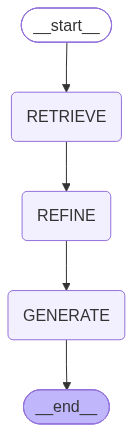

In [11]:
##retriever and generator can be used from above

######
# Strip Creation Step
#####
import re
def decompose_docs(text:str)->List[str]:
    """ Decompose relevant docs based on length """
    text = re.sub(r"\s+"," ",text).strip()
    sentences = re.split(r"(?<=[.!?])\s+",text)
    return [s.strip() for s in sentences if len(s.strip())>20]




####
#Refine
####

def refine(state: State_New)->State_New:

    question = state['question']
    docs = state['retrieved_docs']
    context = "\n".join([ c.page_content for c in docs ])
    strips = decompose_docs(context)
    kept = []

    filtering_prompt= PromptTemplate(
        input_variables=['question','strip'],
        template=""" You are an helpful assistant responsible to judge if the present strip is relevant to the question mentioned.input_types=
        If the strip is relevant, return True
        if it is not relevant or you are not sure, return False
        Question : {question}
        Strip : {strip}
        DO NOT return anything other than TRUE/FALSE
        """
    )
# prompt.format(question=state['question'], retrieved_docs=context)
    for strip in strips:
        dec = llm.invoke(filtering_prompt.format(question=question, strip=strip))
        if dec.casefold()=='TRUE'.casefold() :
            print(dec, type(dec))    
            kept.append(strip)
        

    refined_context = "\n".join(kept)

    return {
        'refined_context' : refined_context,
        'kept_strips' : kept,
        'strips': strips 
    }


graph2 = StateGraph(State_New)
graph2.add_node("RETRIEVE",retrieve_docs)
graph2.add_node("GENERATE",generate_answer)
graph2.add_node("REFINE",refine)
graph2.add_edge(START,"RETRIEVE")
graph2.add_edge("RETRIEVE","REFINE")

graph2.add_edge("REFINE","GENERATE")

graph2.add_edge("GENERATE",END)

app2= graph2.compile()

app2


In [12]:
app_res = app2.invoke({
    "question"  : "Who is Kakashi Hatake",
    "retrieved_docs" :[],
   "strips":[]  , #strips are created to refine and compress the retrieved context in order to improve the generation quality
   "kept_strips" :[],
   "refined_context":[],
   "answer" : ""

})

True <class 'str'>
TRUE <class 'str'>
TRUE <class 'str'>
TRUE <class 'str'>
{'question': 'Who is Kakashi Hatake', 'retrieved_docs': [Document(id='f6622192-bf6d-4e07-bbfe-5e234e7a4244', metadata={}, page_content='Upon graduating from the ninja academy, Naruto is assigned to Team 7, alongside Sakura Haruno and his rival Sasuke Uchiha, under the guidance of Kakashi Hatake. The team embarks on missions that test'), Document(id='ae9bc763-e6fa-4573-b740-11385bb3a801', metadata={}, page_content='within him by the Fourth Hokage to protect his village, Konohagakure (Konoha).'), Document(id='b5e4d54e-456a-457d-9fc5-78a4773f39eb', metadata={}, page_content='Mentorship and Growth: Naruto learns from mentors like Jiraiya and Kakashi, who guide him in mastering powerful techniques and understanding the responsibilities of leadership.'), Document(id='068805e3-dfcf-4e32-b215-0e5bf42c2211', metadata={}, page_content='"Naruto" is a Japanese manga series written and illustrated by Masashi Kishimoto, seri

In [13]:
print("\n\n".join([c.page_content for c in app_res['retrieved_docs']]))

Upon graduating from the ninja academy, Naruto is assigned to Team 7, alongside Sakura Haruno and his rival Sasuke Uchiha, under the guidance of Kakashi Hatake. The team embarks on missions that test

within him by the Fourth Hokage to protect his village, Konohagakure (Konoha).

Mentorship and Growth: Naruto learns from mentors like Jiraiya and Kakashi, who guide him in mastering powerful techniques and understanding the responsibilities of leadership.

"Naruto" is a Japanese manga series written and illustrated by Masashi Kishimoto, serialized from 1999 to 2014, spanning 700 chapters collected in 72 volumes. The story is set in a world of ninja

Orphaned and shunned by villagers due to the demon fox inside him, Naruto grows up craving acknowledgment and dreams of becoming the Hokage, the strongest leader of Konoha. Despite his mischievous


In [14]:
print("\n\n".join([c for c in app_res['strips']]))

Upon graduating from the ninja academy, Naruto is assigned to Team 7, alongside Sakura Haruno and his rival Sasuke Uchiha, under the guidance of Kakashi Hatake.

The team embarks on missions that test within him by the Fourth Hokage to protect his village, Konohagakure (Konoha).

Mentorship and Growth: Naruto learns from mentors like Jiraiya and Kakashi, who guide him in mastering powerful techniques and understanding the responsibilities of leadership.

"Naruto" is a Japanese manga series written and illustrated by Masashi Kishimoto, serialized from 1999 to 2014, spanning 700 chapters collected in 72 volumes.

The story is set in a world of ninja Orphaned and shunned by villagers due to the demon fox inside him, Naruto grows up craving acknowledgment and dreams of becoming the Hokage, the strongest leader of Konoha.

Despite his mischievous


In [15]:
print("\n\n".join([c for c in app_res['kept_strips']]))

Upon graduating from the ninja academy, Naruto is assigned to Team 7, alongside Sakura Haruno and his rival Sasuke Uchiha, under the guidance of Kakashi Hatake.

The team embarks on missions that test within him by the Fourth Hokage to protect his village, Konohagakure (Konoha).

Mentorship and Growth: Naruto learns from mentors like Jiraiya and Kakashi, who guide him in mastering powerful techniques and understanding the responsibilities of leadership.

The story is set in a world of ninja Orphaned and shunned by villagers due to the demon fox inside him, Naruto grows up craving acknowledgment and dreams of becoming the Hokage, the strongest leader of Konoha.


In [ ]:
from pydantic import BaseModel
import json
from langchain_core.output_parsers import PydanticOutputParser

class filter_out(BaseModel):
    score: float
    reason: str

# Output parser bound to the filter_out schema
doc_eval_output_parser = PydanticOutputParser(pydantic_schema=filter_out)

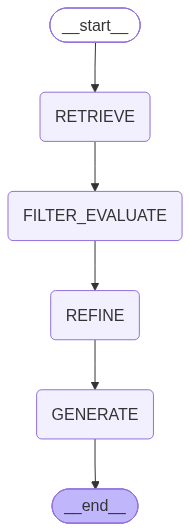

In [51]:
## Threshold based Refinement

UPPER_TH = 0.7
LOWER_TH = 0.3

class State_New_Th():
   question: str
   retrieved_docs : List[Document]
   
   good_docs : List[Document] #Docs with eval score > 0.7
   verdict: str
   reason: str
   
   strips: List[str]   #strips are created to refine and compress the retrieved context in order to improve the generation quality
   kept_strips : List[str]
   refined_context : str

   answer : str




def evaluate_docs(state:State_New_Th)->State_New_Th:
   
   
   doc_eval_prompt = PromptTemplate(
      input_variables=['question','doc'],
      template="""You are a strict retrieval evaluator for RAG.
Return exactly valid JSON with keys `score` and `reason`.

Example output:
{
  "score": 0.85,
  "reason": "The document directly answers the question."
}

Question: {question}
DOC: {doc}
""",
   )

   retrieve_docs = state['retrieved_docs']
   good_docs = []
   try:
      scores = []
      reasons =[]
      for _ in retrieve_docs:
         doc_text = _.page_content if hasattr(_, 'page_content') else str(_)
         
         response = llm.invoke(
               doc_eval_prompt.format(
                  question=state["question"],
                  doc=doc_text,
               )
            )

         response_text = response.content if hasattr(response, "content") else str(response)
         response_text = response_text.replace("```json", "").replace("```", "").strip()

         try:
            res = doc_eval_output_parser.parse(response_text)
         except Exception as e:
            print("Exception occured while validating model:", e)
            res = filter_out.parse_obj(json.loads(response_text))

         if res.score > LOWER_TH:
            good_docs.append(_)
         scores.append(res.score)
         reasons.append(res.reason) 

      if any(s> UPPER_TH for s in scores):
         why = "Docs are greater than Upper Theshold"
         return {
            'good_docs'  : good_docs,
            'verdict': 'CORRECT',
            'reason': f"Atleast one retrived doc is above the score of {UPPER_TH}.{why}"
         }
      if len(scores)>0 and all(s < LOWER_TH for s in scores):
         why = "No chunk is sufficient"
         return {
            'good_docs'  : [],
            'verdict': 'INCORRECT',
            'reason': f"None retrived doc is above the score of {LOWER_TH}. {why}"
         }

      why = 'Mixed Relevance signals'
      return {
            'good_docs'  : good_docs,
            'verdict': 'AMBIGUOUS',
            'reason': f"No Doc is above {UPPER_TH} but not all are < {LOWER_TH}. {why}"
         }

   except Exception as e:
      print(e)
      print('Error occured while retrieving good docs')
      return {
            'good_docs'  : good_docs,
            'verdict': 'INCORRECT',
            'reason': f"No Doc is above {UPPER_TH} but not all are < {LOWER_TH}. "
         }
   



def refine(state: State_New_Th)->State_New_Th:

    question = state['question']
   #  docs = state['retrieved_docs'] Difference is good_docs only
    docs = state['good_docs']# Difference is good_docs only
    context = "\n".join([ c.page_content for c in docs ])
    strips = decompose_docs(context)
    kept = []

    filtering_prompt= PromptTemplate(
        input_variables=['question','strip'],
        template=""" You are an helpful assistant responsible to judge if the present strip is relevant to the question mentioned.input_types=
        If the strip is relevant, return True
        if it is not relevant or you are not sure, return False
        Question : {question}
        Strip : {strip}
        DO NOT return anything other than TRUE/FALSE
        """
    )
# prompt.format(question=state['question'], retrieved_docs=context)
    for strip in strips:
        dec = llm.invoke(filtering_prompt.format(question=question, strip=strip))
        if dec.casefold()=='TRUE'.casefold() :
            print(dec, type(dec))    
            kept.append(strip)
        

    refined_context = "\n".join(kept)

    return {
        'refined_context' : refined_context,
        'kept_strips' : kept,
        'strips': strips 
    }


graph2 = StateGraph(State_New_Th)
graph2.add_node("RETRIEVE",retrieve_docs)
graph2.add_node("GENERATE",generate_answer)
graph2.add_node("FILTER_EVALUATE",evaluate_docs)
graph2.add_node("REFINE",refine)
graph2.add_edge(START,"RETRIEVE")
graph2.add_edge("RETRIEVE","FILTER_EVALUATE")
graph2.add_edge("FILTER_EVALUATE","REFINE")
graph2.add_edge("REFINE","GENERATE")
graph2.add_edge("GENERATE",END)

app3= graph2.compile()

app3

# prompt = doc_eval_prompt.format(question="Who is Kakashi Hatake",doc="Upon graduating from the ninja academy, Naruto is assigned to Team 7, alongside Sakura Haruno and his rival Sasuke Uchiha, under the guidance of Kakashi Hatake.")
# llm.invoke(prompt)


In [52]:
app_res = app3.invoke({
    "question"  : "Who is Kakashi Hatake",
    "retrieved_docs" :[],
   "good_docs":[],
   "verdict":'',
   "reason":'',
   "strips":[]  , #strips are created to refine and compress the retrieved context in order to improve the generation quality
   "kept_strips" :[],
   "refined_context":[],
   "answer" : ""

})

'\n  "score"'
Error occured while retrieving good docs
{'question': 'Who is Kakashi Hatake', 'retrieved_docs': [Document(id='f6622192-bf6d-4e07-bbfe-5e234e7a4244', metadata={}, page_content='Upon graduating from the ninja academy, Naruto is assigned to Team 7, alongside Sakura Haruno and his rival Sasuke Uchiha, under the guidance of Kakashi Hatake. The team embarks on missions that test'), Document(id='ae9bc763-e6fa-4573-b740-11385bb3a801', metadata={}, page_content='within him by the Fourth Hokage to protect his village, Konohagakure (Konoha).'), Document(id='b5e4d54e-456a-457d-9fc5-78a4773f39eb', metadata={}, page_content='Mentorship and Growth: Naruto learns from mentors like Jiraiya and Kakashi, who guide him in mastering powerful techniques and understanding the responsibilities of leadership.'), Document(id='068805e3-dfcf-4e32-b215-0e5bf42c2211', metadata={}, page_content='"Naruto" is a Japanese manga series written and illustrated by Masashi Kishimoto, serialized from 1999 to 2